[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pablolob/calc_dif_equations_LAB/blob/main/09_Epidemiologia_SIR.ipynb)

# 🦠 LAB 9: Modelo SIR — ¿Cuántos hay que vacunar?

Estalla un brote de sarampión en un campus universitario de **1000 personas**. Un infectado entra en contacto con compañeros susceptibles y los contagia, y los contagiados acaban recuperándose con inmunidad. La pregunta del rector: **¿qué porcentaje de la población hay que vacunar para que el brote ni siquiera arranque?**

El modelo **SIR** (Kermack–McKendrick, 1927) es un sistema de **tres EDOs acopladas**:

$$\dfrac{dS}{dt} = -\beta\,\dfrac{S\,I}{N}, \qquad \dfrac{dI}{dt} = \beta\,\dfrac{S\,I}{N} - \gamma\,I, \qquad \dfrac{dR}{dt} = \gamma\,I$$

donde $S$=susceptibles, $I$=infectados, $R$=recuperados, $N=S+I+R$, $\beta$=tasa de contagio (contactos efectivos por persona y día), $\gamma$=tasa de recuperación. Usamos **incidencia dependiente de frecuencia**: cada infectado contacta con una fracción $S/N$ de susceptibles.

Tu misión: implementar el sistema, calcular el **número reproductivo básico** $R_0$ y el **umbral de inmunidad de rebaño**.

---

In [3]:
# !!! ESTA CELDA ES SOLO DE CONFIGURACIÓN.
# Este bloque contiene código auxiliar; ejecútalo para poder visualizar los resultados más adelante.
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

N_TOTAL = 1000   # tamaño del campus

def dibujar_SIR(t, S, I, R, p_vac=0.0):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(t, S, 'b-',  lw=2.2, label='Susceptibles  S(t)')
    ax.plot(t, I, 'r-',  lw=2.2, label='Infectados   I(t)')
    ax.plot(t, R, 'g-',  lw=2.2, label='Recuperados  R(t)')
    ax.axhline(150, color='k', linestyle='--', alpha=0.5, label='Capacidad UCI (150)')
    titulo = 'Brote SIR sin vacunación' if p_vac == 0 else f'Brote SIR con cobertura vacunal del {p_vac*100:.0f}%'
    ax.set_title(titulo)
    ax.set_xlabel('Tiempo (días)'); ax.set_ylabel('Número de personas')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def mapa_R0_vacunacion(beta, gamma):
    """Heatmap del tamaño final del brote en función de R0 y la cobertura vacunal."""
    p_grid    = np.linspace(0, 1, 50)
    R0_grid   = np.linspace(0.5, 18, 50)
    final_attack = np.zeros((len(R0_grid), len(p_grid)))

    def sir(y, t, beta_, gamma_):
        S, I, R = y
        return [-beta_*S*I/N_TOTAL, beta_*S*I/N_TOTAL - gamma_*I, gamma_*I]

    t_sim = np.linspace(0, 200, 200)
    for i, R0 in enumerate(R0_grid):
        beta_eff = R0 * gamma
        for j, p in enumerate(p_grid):
            S0 = (1 - p) * N_TOTAL - 1
            res = odeint(sir, [S0, 1, p*N_TOTAL], t_sim, args=(beta_eff, gamma))
            final_attack[i, j] = res[-1, 2] - p*N_TOTAL  # nuevos contagios

    fig, ax = plt.subplots(figsize=(9, 6))
    im = ax.imshow(final_attack, origin='lower', aspect='auto', cmap='Reds',
                   extent=[p_grid.min()*100, p_grid.max()*100, R0_grid.min(), R0_grid.max()])
    plt.colorbar(im, ax=ax, label='Tamaño del brote (personas contagiadas)')
    p_critico = 1 - 1/R0_grid
    ax.plot(p_critico*100, R0_grid, 'b--', lw=2.5, label=r'Umbral $p^* = 1 - 1/R_0$')
    for nombre, R0_v in [('Gripe', 1.3), ('COVID', 2.5), ('Varicela', 8), ('Sarampión', 15)]:
        if R0_grid.min() < R0_v < R0_grid.max():
            ax.axhline(R0_v, color='black', linestyle=':', alpha=0.4)
            ax.text(2, R0_v + 0.1, f'{nombre}  R₀≈{R0_v}', fontsize=9)
    ax.set_xlabel('Cobertura vacunal (%)'); ax.set_ylabel(r'$R_0$')
    ax.set_title('Tamaño del brote según vacunación y contagiosidad')
    ax.legend(loc='lower left'); plt.tight_layout(); plt.show()

## 🔬 Conceptos clave

**Número reproductivo básico**:
$$R_0 = \dfrac{\beta}{\gamma}$$
Es el número promedio de personas que un infectado contagia en una población totalmente susceptible. Si $R_0 > 1$ → epidemia. Si $R_0 < 1$ → se extingue.

**Inmunidad de rebaño**: si vacunamos una fracción $p$ de la población, el número reproductivo efectivo es $R_e = R_0(1-p)$. Para que el brote no arranque necesitamos $R_e < 1$, lo que da:
$$\boxed{\;p^* = 1 - \dfrac{1}{R_0}\;}$$

<details>
<summary><b>¿Por qué la epidemia no arranca cuando $S/N < \gamma/\beta$?</b></summary>

Mira la EDO de los infectados:
$$\dfrac{dI}{dt} = \left(\beta\,\dfrac{S}{N} - \gamma\right)I$$
Si en el instante inicial $\beta\,S(0)/N < \gamma$ entonces $\dot{I}(0) < 0$: cada infectado contagia a menos de uno antes de recuperarse, y el brote decae monótonamente desde el primer día.
</details>

---

### 🛠️ ¡TU TURNO! — Implementa el modelo SIR

1. Completa la función `modelo_SIR(y, t, beta, gamma)` con las tres EDOs
2. Calcula $R_0$
3. Calcula el umbral de inmunidad de rebaño $p^*$

R0 del sarampión en el campus:  R0 = 15.00
Umbral de inmunidad de rebaño:  p* = 93.3 %


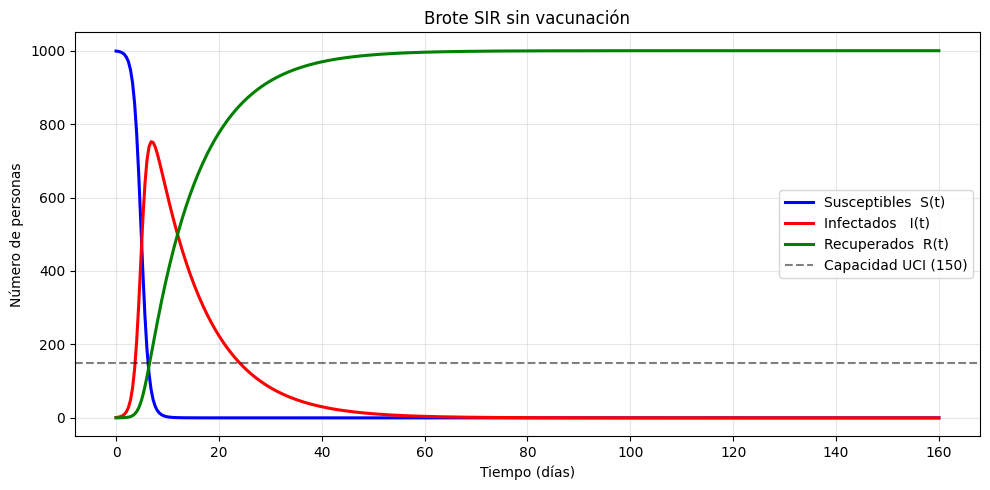

In [ ]:
# Parámetros del sarampión en el campus
beta  = 1.5    # contactos efectivos por persona infectada y día
gamma = 0.1    # los infectados se recuperan en ~10 días (1/gamma)

def modelo_SIR(y, t, beta, gamma):
    S, I, R = y
    dSdt = None    # <--- ¡Tu turno 1!  (incidencia dependiente de frecuencia: usa S*I/N_TOTAL)
    dIdt = None    # <--- ¡Tu turno 1!
    dRdt = None    # <--- ¡Tu turno 1!
    return [dSdt, dIdt, dRdt]

R0 = None    # <--- ¡Tu turno 2!
p_star = None    # <--- ¡Tu turno 3!

print(f'R0 del sarampión en el campus:  R0 = {R0:.2f}')
print(f'Umbral de inmunidad de rebaño:  p* = {p_star*100:.1f} %')

# Simulamos el brote sin vacunación
t = np.linspace(0, 160, 400)
S0, I0, R0_init = N_TOTAL - 1, 1, 0
sol = odeint(modelo_SIR, [S0, I0, R0_init], t, args=(beta, gamma))
S, I, R = sol.T
dibujar_SIR(t, S, I, R)

<details>
<summary><b>¿Atascado? Haz clic aquí para ver la Solución</b></summary>

```python
dSdt = -beta * S * I / N_TOTAL
dIdt =  beta * S * I / N_TOTAL - gamma * I
dRdt =  gamma * I

R0 = beta / gamma
p_star = 1 - 1 / R0
```
</details>

### 💉 Efecto de la vacunación

Repite la simulación con distintas coberturas vacunales. Vacunar significa empezar la simulación con menos susceptibles: $S(0) = (1-p)\,N$.

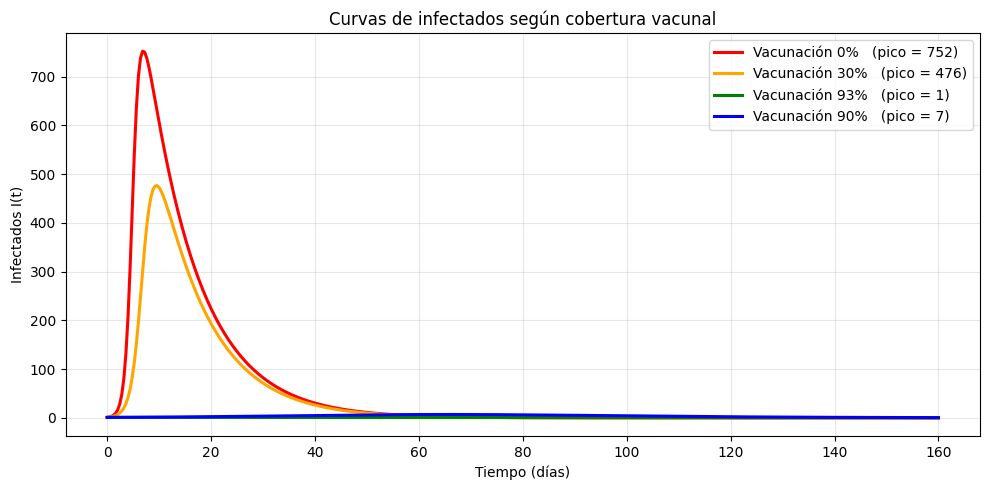

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for p_vac, color in zip([0.0, 0.3, p_star, 0.9], ['red', 'orange', 'green', 'blue']):
    S0 = (1 - p_vac) * N_TOTAL - 1
    sol = odeint(modelo_SIR, [S0, 1, p_vac*N_TOTAL], t, args=(beta, gamma))
    ax.plot(t, sol[:, 1], color=color, lw=2.2,
            label=f'Vacunación {p_vac*100:.0f}%   (pico = {sol[:,1].max():.0f})')
ax.set_title('Curvas de infectados según cobertura vacunal')
ax.set_xlabel('Tiempo (días)'); ax.set_ylabel('Infectados I(t)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 🌍 Mapa global — ¿Por qué el sarampión exige el 93%?

A partir de este modelo se podría calcular la tasa de vacunación necesaria para evitar brotes de enfermedades.

La celda siguiente muestra, para distintas enfermedades reales (valores plausibles pero simplificados y fijados exclusivamente con fines didácticos), qué cobertura vacunal evita el brote. La línea azul es la frontera teórica $p^* = 1 - 1/R_0$.

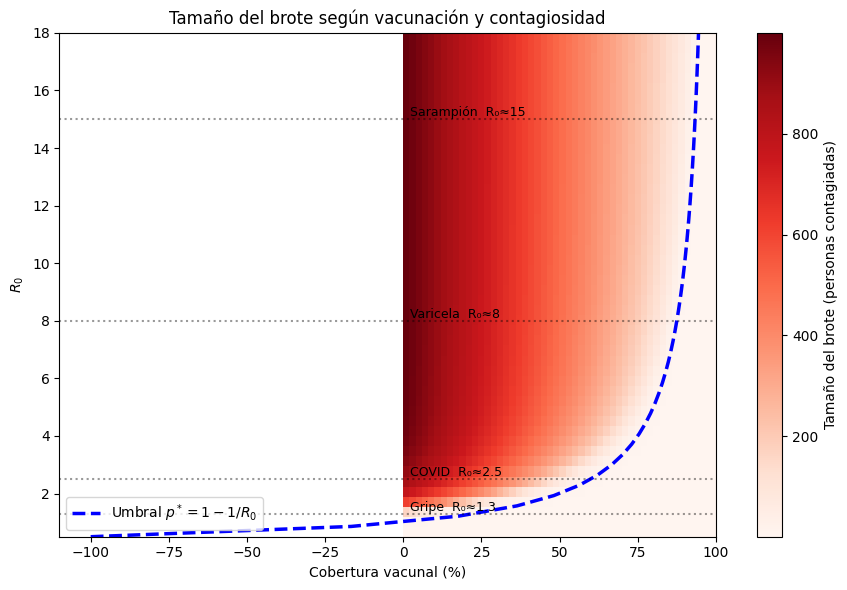

In [5]:
mapa_R0_vacunacion(beta, gamma)

### 🔍 Experimenta y Reflexiona

- **Cuarentena**: reduce $\beta$ a la mitad (distancia social). ¿Qué pasa con $R_0$ y con el pico?
- **Tratamiento que acorta la enfermedad**: dobla $\gamma$. ¿Es equivalente a vacunar?
- **Comparación**: prueba parámetros de COVID ($R_0\approx 2.5$) y de gripe ($R_0\approx 1.3$). ¿Por qué la gripe estacional no se erradica con vacunación?

---

## 📚 Referencias

**Kermack, W.O. & McKendrick, A.G. (1927).** *A contribution to the mathematical theory of epidemics.* Proceedings of the Royal Society A, 115(772), 700–721.  
[→ DOI: 10.1098/rspa.1927.0118](https://doi.org/10.1098/rspa.1927.0118)

**Anderson, R.M. & May, R.M. (1991).** *Infectious Diseases of Humans: Dynamics and Control.* Oxford University Press.

**Fine, P., Eames, K. & Heymann, D.L. (2011).** *"Herd Immunity": A Rough Guide.* Clinical Infectious Diseases, 52(7), 911–916.  
[→ DOI: 10.1093/cid/cir007](https://doi.org/10.1093/cid/cir007)

---

## Mis Respuestas

**Pregunta 1.**

*Escribe aquí tu respuesta...*

---

**Pregunta 2.**

*Escribe aquí tu respuesta...*

---